# Word2Vec + t-SNE Visualization (Robust Upload)

This notebook trains a **Word2Vec** model and visualizes word embeddings with **t-SNE**.
You can use the demo corpus or **upload your own `.txt` file** (one document per line).

In [1]:
import sys
%matplotlib inline
!{sys.executable} -m pip install --quiet gensim scikit-learn matplotlib nltk ipywidgets
import ipywidgets as widgets
from IPython.display import display, clear_output


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [2]:
import random
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from gensim.parsing.preprocessing import (
    preprocess_string, strip_punctuation, strip_numeric, strip_multiple_whitespaces,
    strip_short, strip_non_alphanum, strip_tags, remove_stopwords
)
import nltk
nltk.download('punkt', quiet=True)
random.seed(42)
np.random.seed(42)
filters = [strip_tags, strip_punctuation, strip_non_alphanum, strip_numeric, remove_stopwords, strip_multiple_whitespaces, strip_short]

## Demo Data
Feel free to modify `demo_texts` or switch to the Upload/Text Area section below.

In [3]:
demo_texts = [
    "Artificial intelligence is transforming many industries.",
    "Neural networks learn patterns from data.",
    "Language models generate helpful answers.",
    "Machine learning requires data and compute.",
    "Visualization with TSNE helps explore vector spaces.",
    "Word2Vec projects words into a continuous space.",
    "Similar words are closer in the embedding space.",
]
tokenized_demo = [preprocess_string(t.lower(), filters) for t in demo_texts]
tokenized_demo = [s for s in tokenized_demo if len(s) > 0]
len(tokenized_demo)

7

## Train + Visualize (Demo)

/opt/homebrew/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


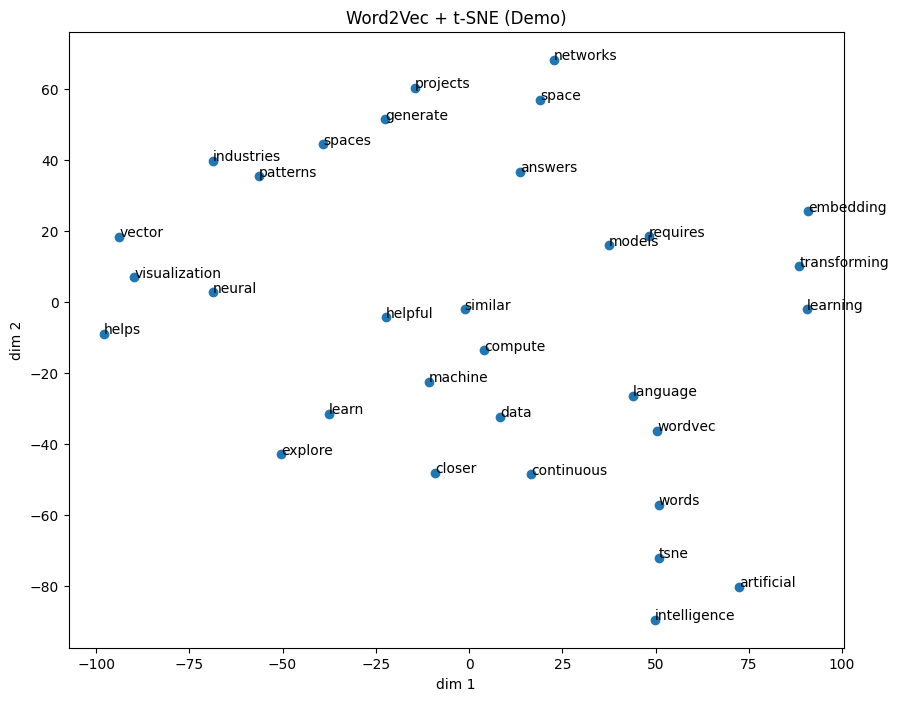

In [4]:
w2v = Word2Vec(sentences=tokenized_demo, vector_size=100, window=5, min_count=1, workers=2, sg=1, epochs=200)
vocab = list(w2v.wv.key_to_index.keys())
words = vocab[: min(200, len(vocab))]
X = np.array([w2v.wv[w] for w in words])
perplexity = min(5, max(2, len(words)//3))
tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate='auto', init='random', random_state=42, n_iter=1500)
X2 = tsne.fit_transform(X)
plt.figure(figsize=(10,8))
plt.scatter(X2[:,0], X2[:,1])
for i, w in enumerate(words):
    plt.annotate(w, (X2[i,0], X2[i,1]))
plt.title('Word2Vec + t-SNE (Demo)')
plt.xlabel('dim 1')
plt.ylabel('dim 2')
plt.show()

## Exercise:


Write an application that:

- uploads a `.txt` file (UTF-8, one document per line)
- trains Word2Vec
- visualizes the words with TSNE

Using the full text of the Harry Potter and the Philosopher's Stone book as input.

In [ ]:
upload = widgets.FileUpload(
    accept='.txt',
    multiple=False,
    description='Upload .txt file'
)

train_button = widgets.Button(
    description='Train & Visualize',
    button_style='success',
    disabled=True
)

output = widgets.Output()

def load_and_parse_file(uploaded_file):
    """Load uploaded file and parse into lines"""
    content = uploaded_file['content']
    text = bytes(content).decode('utf-8')
    lines = [line.strip() for line in text.split('\n') if line.strip()]
    return lines

def preprocess_documents(lines):
    """Tokenize and preprocess text documents"""
    tokenized_texts = [preprocess_string(line.lower(), filters) for line in lines]
    tokenized_texts = [s for s in tokenized_texts if len(s) > 0]
    return tokenized_texts

def train_word2vec(tokenized_texts):
    """Train Word2Vec model on tokenized documents"""
    model = Word2Vec(
        sentences=tokenized_texts,
        vector_size=100,
        window=5,
        min_count=1,
        workers=2,
        sg=1,
        epochs=100
    )
    return model

def visualize_embeddings(model, max_words=200):
    """Apply t-SNE and visualize word embeddings"""
    vocab = list(model.wv.key_to_index.keys())
    
    if len(vocab) < 2:
        print("Not enough words to visualize!")
        return
    
    words_to_plot = vocab[:min(max_words, len(vocab))] 
    X = np.array([model.wv[w] for w in words_to_plot])
    
    print("Applying t-SNE dimensionality reduction...")
    perplexity = min(30, max(2, len(words_to_plot) // 3))
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate='auto',
        init='random',
        random_state=42,
        max_iter=1500
    )
    X_embedded = tsne.fit_transform(X)
    
    plt.figure(figsize=(12, 10))
    plt.scatter(X_embedded[:, 0], X_embedded[:, 1], alpha=0.6)
    
    for i, word in enumerate(words_to_plot):
        plt.annotate(
            word,
            (X_embedded[i, 0], X_embedded[i, 1]),
            fontsize=8,
            alpha=0.7
        )
    
    plt.title(f'Word2Vec + t-SNE Visualization ({len(words_to_plot)} words)', fontsize=14)
    plt.xlabel('t-SNE dimension 1')
    plt.ylabel('t-SNE dimension 2')
    plt.tight_layout()
    plt.show()

def on_upload_change(change):
    """Enable train button when file is uploaded"""
    if upload.value:
        train_button.disabled = False
    else:
        train_button.disabled = True

def on_train_click(b):
    """Process uploaded file, train Word2Vec, and visualize"""
    with output:
        clear_output()
        
        if not upload.value:
            print("Please upload a file first!")
            return
        
        try:
            uploaded_file = upload.value[0]
            lines = load_and_parse_file(uploaded_file)
            print(f"Loaded {len(lines)} documents from file")
            
            tokenized_texts = preprocess_documents(lines)
            if not tokenized_texts:
                print("No valid text found after preprocessing!")
                return
            print(f"Preprocessed {len(tokenized_texts)} documents")
            
            print("Training Word2Vec model...")
            model = train_word2vec(tokenized_texts)
            vocab_size = len(model.wv.key_to_index)
            print(f"Vocabulary size: {vocab_size}")
            
            visualize_embeddings(model)
            print("✓ Complete!")
            
        except Exception as e:
            print(f"Error: {str(e)}")
            import traceback
            traceback.print_exc()

# Connect event handlers
upload.observe(on_upload_change, names='value')
train_button.on_click(on_train_click)

# Display widgets
display(upload)
display(train_button)
display(output)

FileUpload(value=(), accept='.txt', description='Upload .txt file')

Button(button_style='success', description='Train & Visualize', disabled=True, style=ButtonStyle())

Output()